In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_curve, auc


In [3]:
!ls /content/drive/MyDrive

 149		  'CamScanner 10-03-2024 17.16.pdf'   IMG-20250502-WA0006.jpg
'220149 (1).pdf'   Classroom			      ml
 220149.pdf	  'Colab Notebooks'		      SDP_labrep_220149.pdf


In [4]:
df = pd.read_csv('/content/sample_data/heart.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
imputer = SimpleImputer(strategy='mean')

df[df.columns] = imputer.fit_transform(df)

In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
X = df.drop('target', axis=1)
y = df['target']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
svm_model = SVC(probability=True)

svm_model.fit(X_train, y_train)

SVC(probability=True)

In [16]:
y_pred = svm_model.predict(X_test)

In [17]:
param_grid = {
    'C':[0.1,1,10],
    'gamma':[1,0.1,0.01],
    'kernel':['linear','rbf','poly'],
    'degree':[2,3]
}

In [18]:
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    verbose=2,
    cv=3
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, 

GridSearchCV(cv=3, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3],
                         'gamma': [1, 0.1, 0.01],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=2)

In [19]:
print(grid.best_params_)

{'C': 10, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}


In [20]:
best_svm = grid.best_estimator_

In [21]:
y_pred = best_svm.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       102
         1.0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



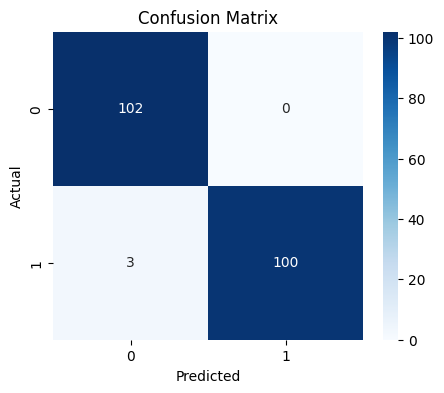

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
y_prob = best_svm.predict_proba(X_test)[:,1]

In [26]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9985722444317533


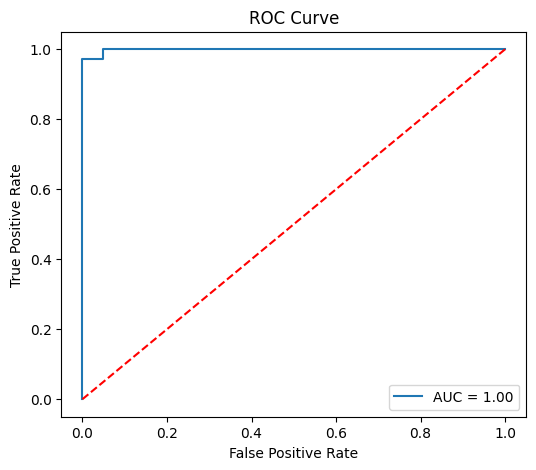

In [27]:
plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,
         label='AUC = %0.2f'%roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [28]:
sample = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

sample.head(10)

,Actual,Predicted,Probability
0,1.0,1.0,9.974746e-01
1,1.0,1.0,1.000000e+00
2,0.0,0.0,1.239265e-02
3,1.0,1.0,9.999827e-01
4,0.0,0.0,1.238229e-02
5,1.0,1.0,9.593476e-01
6,0.0,0.0,1.000000e-07
7,0.0,0.0,1.309547e-05
8,1.0,1.0,9.999879e-01
9,0.0,0.0,1.000000e-07


In [29]:
X2 = df[['age','chol']]
y2 = df['target']

In [30]:
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2)

In [31]:
svm2 = SVC(kernel='rbf')

svm2.fit(X2,y2)

SVC()

In [33]:
from mlxtend.plotting import plot_decision_regions

In [34]:
!pip install mlxtend

In [37]:
y2 = y2.astype(int)


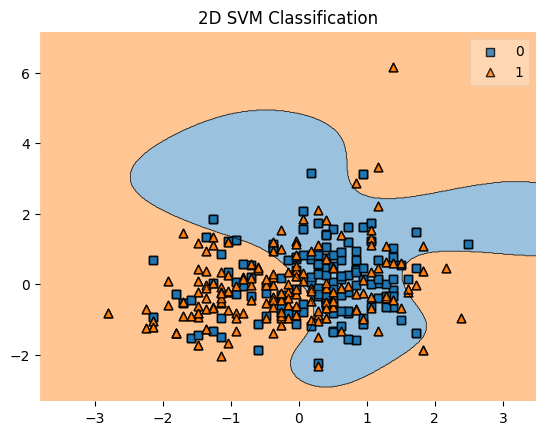

In [38]:
from mlxtend.plotting import plot_decision_regions

y2 = y2.astype(int)

plot_decision_regions(
    X2,
    y2.values,
    clf=svm2
)

plt.title('2D SVM Classification')
plt.show()